In [43]:
from neural_priors.utils.data import Subject, get_all_subject_ids
from tqdm.contrib.itertools import product
import pandas as pd
import seaborn as sns

In [44]:
fit_responses_ = [True,False]
censored = [True, False]
subjects = get_all_subject_ids()
models = [3, 5]

In [85]:
df = []

for subject, model_label, fit_responses, cens in product(subjects, models, fit_responses_, censored):
    try:
        d = Subject(subject).get_prf_parameters_volume(roi='NPCr', model_label=model_label, response_fit=fit_responses, censored=cens)
        d['subject'] = subject
        d['model_label'] = model_label
        d['fit_responses'] = fit_responses
        d['censored'] = cens
        df.append(d.set_index(['subject', 'model_label', 'fit_responses', 'censored'], append=True))
    except Exception as e:
        print(f"Error processing subject {subject}, model {model_label}, fit_responses {fit_responses}, censored {cens}: {e}")

df = pd.concat(df)


df.to_csv('/data/ds-neuralpriors/derivatives/summary_tsvs/censored_models.tsv', sep='\t')

  0%|          | 0/312 [00:00<?, ?it/s]

In [102]:
df = pd.read_csv('/data/ds-neuralpriors/derivatives/summary_tsvs/censored_models.tsv', sep='\t', index_col=[0,1,2,3,4], header=[0,1])

In [103]:
df

parameter                                              mu             \
range                                              narrow       wide   
    subject model_label fit_responses censored                         
0   1       3           True          True       8.324986   8.522818   
1   1       3           True          True      12.597792   8.339407   
2   1       3           True          True      13.421589  28.472174   
3   1       3           True          True      14.084457  28.671478   
4   1       3           True          True       7.368360   7.868102   
...                                                   ...        ...   
689 41      5           False         False     10.811555  15.037331   
690 41      5           False         False      8.861952   8.861952   
691 41      5           False         False     10.887302  15.507496   
692 41      5           False         False     10.253930  11.576147   
693 41      5           False         False     10.948640  15.888218   

parameter                                             sd           delta_wide  \
range                                             narrow      wide     narrow   
    subject model_label fit_responses censored                                  
0   1       3           True          True      0.092109  0.092109   0.862807   
1   1       3           True          True      0.210603  0.210603   2.495218   
2   1       3           True          True      0.428306  0.428306   4.175973   
3   1       3           True          True      0.139760  0.139760   3.882622   
4   1       3           True          True      0.158643  0.158643   0.811798   
...                                                  ...       ...        ...   
689 41      5           False         False     0.897885  0.897885   6.207011   
690 41      5           False         False     0.169920  0.169920   6.207011   
691 41      5           False         False     0.906622  0.906622   6.207011   
692 41      5           False         False     0.385009  0.385009   6.207011   
693 41      5           False         False     1.148616  1.148616   6.207011   

parameter                                                amplitude            \
range                                               wide    narrow      wide   
    subject model_label fit_responses censored                                 
0   1       3           True          True      0.862807  2.745410  2.745410   
1   1       3           True          True      2.495218  0.276122  0.276122   
2   1       3           True          True      4.175973  0.341537  0.341537   
3   1       3           True          True      3.882622  0.273743  0.273743   
4   1       3           True          True      0.811798  3.594358  3.594358   
...                                                  ...       ...       ...   
689 41      5           False         False     6.207011  0.514373  0.514373   
690 41      5           False         False     6.207011  0.104438  0.104438   
691 41      5           False         False     6.207011  0.572894  0.572894   
692 41      5           False         False     6.207011  0.195074  0.195074   
693 41      5           False         False     6.207011  0.731971  0.731971   

parameter                                       baseline                  r2  \
range                                             narrow      wide       nan   
    subject model_label fit_responses censored                                 
0   1       3           True          True     -0.080390 -0.080390  0.006567   
1   1       3           True          True     -0.545310 -0.545310  0.006507   
2   1       3           True          True     -0.705960 -0.705960  0.010538   
3   1       3           True          True     -0.309580 -0.309580  0.012157   
4   1       3           True          True     -0.094270 -0.094270  0.016289   
...                                                  ...       ...       ...   
689 41      5  

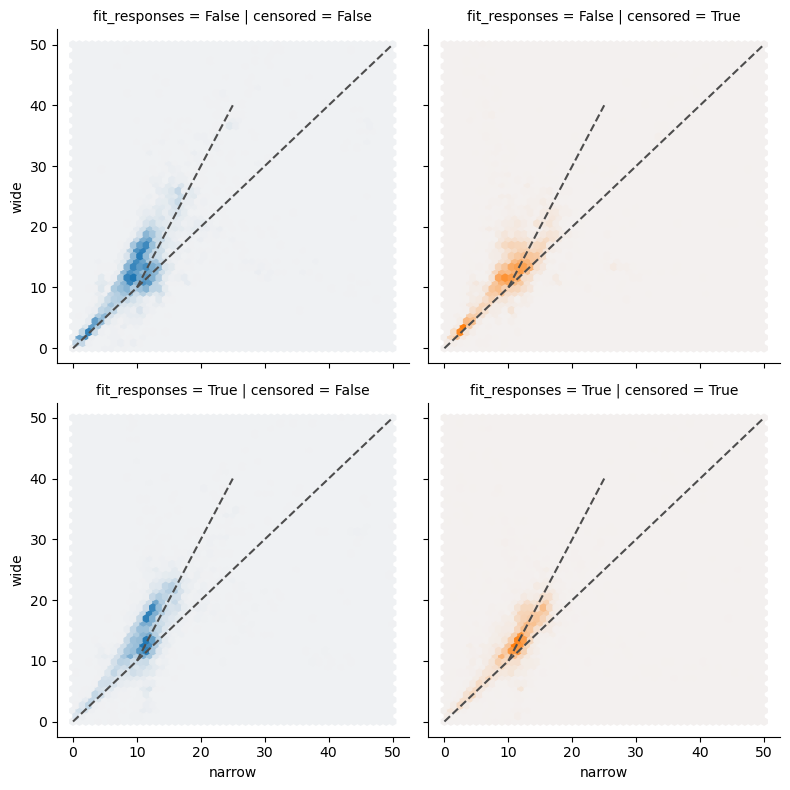

In [104]:
import matplotlib.pyplot as plt
mus = df[df[('cvr2', 'nan')] > 0.0]['mu']

def hexbin(x, y, color, **kwargs):
    cmap = sns.light_palette(color, as_cmap=True)
    plt.hexbin(x, y, gridsize=50, cmap=cmap, **kwargs)

g = sns.FacetGrid(mus.xs(3, level='model_label').reset_index(), col="censored", hue='censored', height=4, row='fit_responses')
g.map(hexbin, "narrow", "wide", extent=[0, 50, 0, 50])

# Identity line
for ax in g.axes.flatten():
    ax.plot([0, 50], [0, 50], ls="--", c=".3")

for ax in g.axes.flatten():
    #plot [10, 10] to [25, 40]
    ax.plot([10, 25], [10, 40], ls="--", c=".3")

In [105]:
import pingouin as pg
median_mu = df[df[('cvr2', 'nan')] > 0.0].xs(3, level='model_label').groupby(['subject', 'censored', 'fit_responses'])['mu'].median()

median_mu.groupby(['censored', 'fit_responses']).apply(lambda x: pg.ttest(x[('mu', 'wide')], x[('mu', 'narrow')], paired=True, alternative='greater'))

T  dof alternative         p-val  \
censored fit_responses                                                   
False    False         T-test  4.862673   38     greater  1.018482e-05   
         True          T-test  8.813951   38     greater  5.047040e-11   
True     False         T-test  1.443655   38     greater  7.851522e-02   
         True          T-test  5.602540   38     greater  9.989381e-07   

                                      CI95%   cohen-d       BF10     power  
censored fit_responses                                                      
False    False         T-test   [1.87, inf]  0.699375   2097.225  0.995894  
         True          T-test   [2.43, inf]  1.063429  2.013e+08  0.999999  
True     False         T-test  [-0.15, inf]  0.199291      0.897  0.336350  
         True          T-test   [1.25, inf]  0.613060  1.795e+04  0.982754

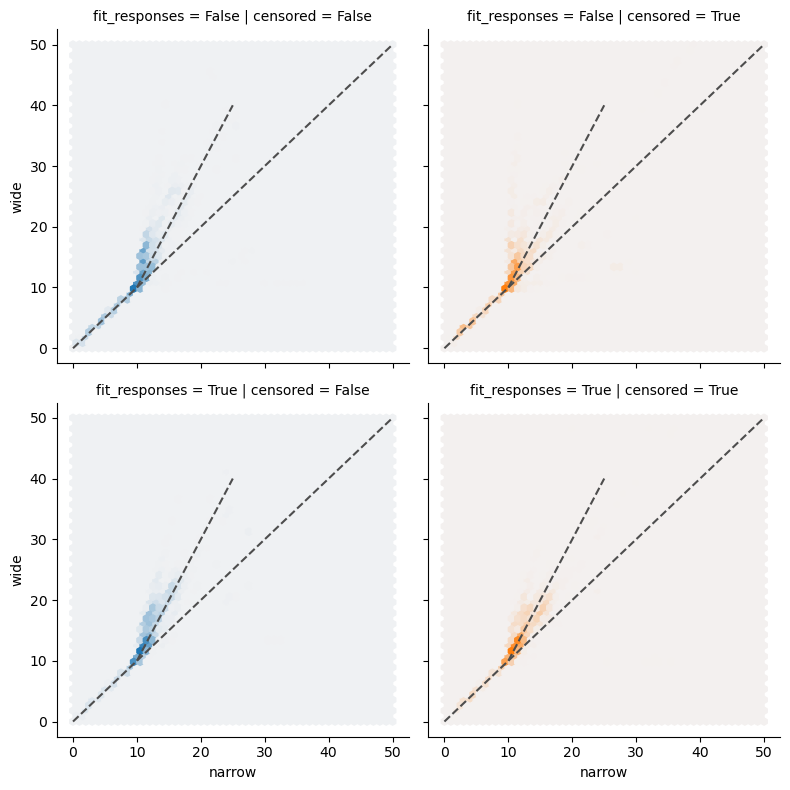

In [106]:
import matplotlib.pyplot as plt
mus = df[df[('cvr2', 'nan')] > 0.0]['mu']

def hexbin(x, y, color, **kwargs):
    cmap = sns.light_palette(color, as_cmap=True)
    plt.hexbin(x, y, gridsize=50, cmap=cmap, **kwargs)

g = sns.FacetGrid(mus.xs(5, level='model_label').reset_index(), col="censored", hue='censored', height=4, row='fit_responses')
g.map(hexbin, "narrow", "wide", extent=[0, 50, 0, 50])

# Identity line
for ax in g.axes.flatten():
    ax.plot([0, 50], [0, 50], ls="--", c=".3")

for ax in g.axes.flatten():
    #plot [10, 10] to [25, 40]
    ax.plot([10, 25], [10, 40], ls="--", c=".3")

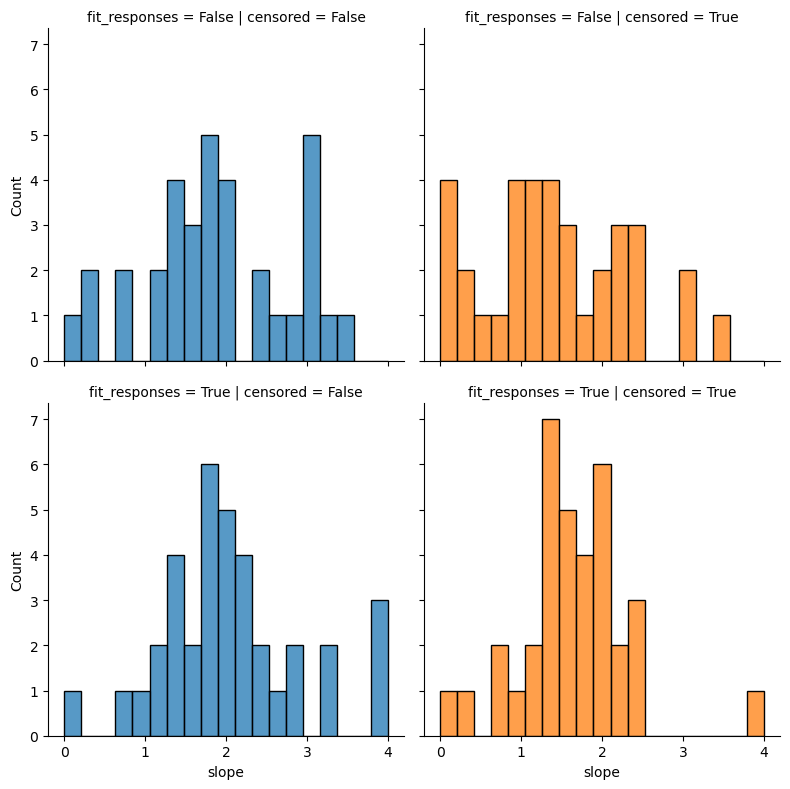

In [107]:
import numpy as np
tmp = slopes.groupby(['fit_responses', 'subject', 'censored']).mean().to_frame('slope')

g = sns.FacetGrid(tmp.reset_index(), col="censored", hue='censored', height=4, row='fit_responses')
g.map(sns.histplot, "slope", bins=np.linspace(0, 4, 20))

In [108]:
slopes.groupby(['subject', 'censored', 'fit_responses']).mean().groupby(['censored', 'fit_responses']).apply(lambda x: pg.ttest(x, 1.0, alternative='greater'))

T  dof alternative         p-val  \
censored fit_responses                                                   
False    False         T-test  5.587898   38     greater  1.046184e-06   
         True          T-test  6.727849   38     greater  2.877511e-08   
True     False         T-test  2.373193   38     greater  1.139809e-02   
         True          T-test  4.554136   38     greater  2.643960e-05   

                                     CI95%   cohen-d       BF10     power  
censored fit_responses                                                     
False    False         T-test  [1.92, inf]  0.894780  1.719e+04  0.999939  
         True          T-test  [1.94, inf]  1.077318   4.95e+05  1.000000  
True     False         T-test  [1.35, inf]  0.380015      4.107  0.753562  
         True          T-test  [1.66, inf]  0.729245    874.829  0.997645

(0.0, 4.0)

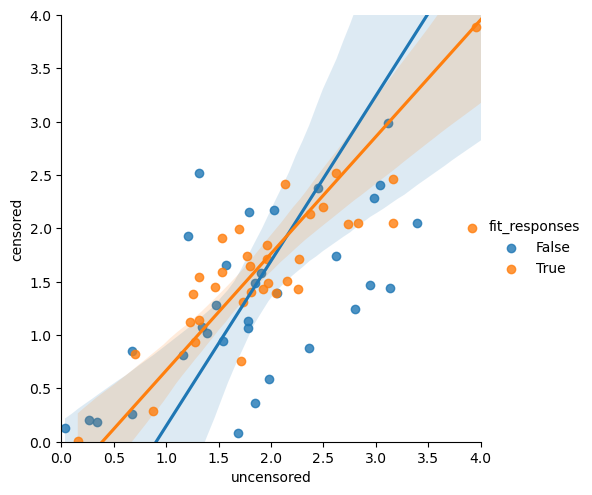

In [109]:
tmp = slopes.unstack('censored').groupby(['subject', 'fit_responses']).mean()

tmp.columns = ['uncensored', 'censored']

sns.lmplot(data=tmp.reset_index(), x='uncensored', y='censored', hue='fit_responses')
plt.xlim(0,4)
plt.ylim(0,4)